<a href="https://colab.research.google.com/github/kbfkaif04/Colab-Notebooks-/blob/main/nlp_disaster_tweets_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing with Disaster Tweets

## Step-by-Step Kaggle NLP Classification Project

### Objective

Build a complete NLP pipeline to predict whether a tweet is about a **real disaster** (`1`) or **not a real disaster** (`0`).

This project uses the Kaggle **Natural Language Processing with Disaster Tweets** dataset.

According to the Kaggle competition materials:

- `train.csv` contains the labeled training examples.
- `test.csv` contains the unlabeled test examples.
- Each tweet has `text`, and may also have `keyword` and `location`.
- The target is binary: `1` = real disaster, `0` = not a real disaster.
- The competition is evaluated using **F1 score**.

Source: [Kaggle — Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/overview)

> **Important:** Because Kaggle evaluates this competition using F1, this notebook focuses on F1 rather than optimizing accuracy alone.


## Project Workflow

1. Import libraries.
2. Load the supplied Kaggle files.
3. Inspect the data and class balance.
4. Check missing values and duplicates.
5. Clean and combine tweet text, keyword, and location.
6. Visualize basic text statistics.
7. Split the training data into training and validation sets.
8. Convert text to TF-IDF features using both word and character n-grams.
9. Compare multiple NLP classifiers.
10. Tune the strongest model.
11. Optimize the probability threshold for F1.
12. Evaluate the final model.
13. Retrain on all labeled data.
14. Generate predictions for `test.csv`.
15. Create and validate `submission.csv`.


## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


## 2. Load the Supplied Kaggle Files

This notebook is designed for the three files provided with the project:

- `train.csv`
- `test.csv`
- `sample_submission.csv`

The code below works in Google Colab when the files are uploaded to `/content/`, and also works in a local Jupyter environment when the files are in the current folder.


In [ ]:
def find_file(filename):
    candidates = [
        Path("/content") / filename,
        Path("/kaggle/input") / filename,
        Path(".") / filename,
    ]

    for path in candidates:
        if path.exists():
            return path

    # Search recursively in the common roots
    for root in [Path("/content"), Path("/kaggle/input"), Path(".")]:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]

    return None


train_path = find_file("train.csv")
test_path = find_file("test.csv")
sample_submission_path = find_file("sample_submission.csv")

print("train.csv:", train_path)
print("test.csv:", test_path)
print("sample_submission.csv:", sample_submission_path)

for path in [train_path, test_path, sample_submission_path]:
    if path is None:
        raise FileNotFoundError(
            "A required file was not found. Please upload "
            "train.csv, test.csv, and sample_submission.csv."
        )

print("\n✅ All required files found!")


train.csv: /content/train.csv
test.csv: /content/test.csv
sample_submission.csv: /content/sample_submission.csv

✅ All required files found!


## 3. Load the Data

In [ ]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

display(train_df.head())


Training shape: (7613, 5)
Test shape: (3263, 4)
Sample submission shape: (3263, 2)

Training columns:
['id', 'keyword', 'location', 'text', 'target']

Test columns:
['id', 'keyword', 'location', 'text']

Sample submission columns:
['id', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 4. Basic Data Inspection

In [ ]:
print("Training data types:")
display(train_df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(train_df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", train_df.duplicated().sum())

print("\nTarget distribution:")
display(
    train_df["target"]
    .value_counts()
    .rename_axis("target")
    .to_frame("count")
)

target_percent = train_df["target"].value_counts(normalize=True) * 100
print("\nTarget percentages:")
display(target_percent.rename("percentage"))


Training data types:


,dtype
id,int64
keyword,object
location,object
text,object
target,int64



Missing values:


,missing_values
id,0
keyword,61
location,2533
text,0
target,0



Duplicate rows: 0

Target distribution:


,count
target,
0,4342
1,3271



Target percentages:


,percentage
target,
0,57.034021
1,42.965979


## 5. Visualize the Target Distribution

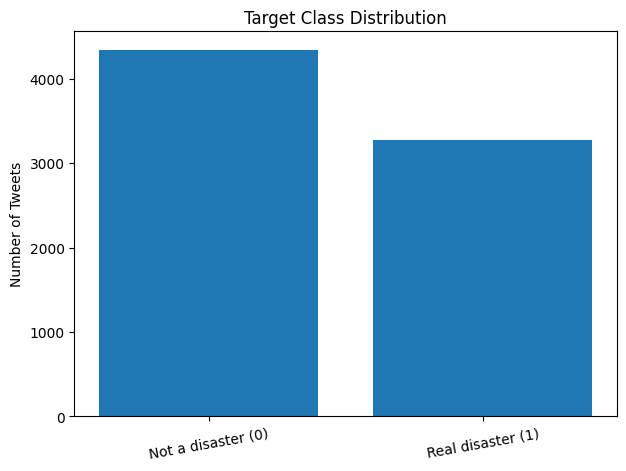

In [ ]:
plt.figure(figsize=(7, 5))

counts = train_df["target"].value_counts().sort_index()

plt.bar(
    ["Not a disaster (0)", "Real disaster (1)"],
    counts.values
)

plt.title("Target Class Distribution")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=10)
plt.show()


## 6. Prepare the Text

The strongest signal comes from the tweet text, but Kaggle also provides:

- `keyword`
- `location`

Missing values are replaced with empty strings.

The cleaning function:

- converts text to lowercase,
- replaces URLs with a common token,
- replaces user mentions with a common token,
- preserves hashtag words,
- replaces numbers with a common token,
- normalizes whitespace.

We then combine the fields into one text representation.


In [ ]:
def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()

    # Replace URLs
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)

    # Replace user mentions
    text = re.sub(r"@\w+", " USER ", text)

    # Keep the word after a hashtag
    text = re.sub(r"#(\w+)", r" \1 ", text)

    # Decode a common HTML entity used in tweets
    text = re.sub(r"&amp;", " and ", text)

    # Normalize numbers
    text = re.sub(r"\d+", " NUM ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def build_combined_text(df):
    keyword = df["keyword"].fillna("").astype(str).str.replace("%20", " ", regex=False)
    location = df["location"].fillna("").astype(str)
    text = df["text"].fillna("").astype(str)

    keyword = keyword.map(clean_text)
    location = location.map(clean_text)
    text = text.map(clean_text)

    # Repeating the keyword once gives it a little more weight
    combined = (
        keyword + " " +
        text + " " +
        location
    )

    return combined.values


all_text = build_combined_text(train_df)
test_text = build_combined_text(test_df)

print("Example cleaned tweet:")
print(all_text[0])


Example cleaned tweet:
 our deeds are the reason of this earthquake may allah forgive us all 


## 7. Basic Text Statistics

Before modeling, inspect tweet length.

Very short messages and long messages can behave differently, and checking these distributions is a useful part of NLP exploratory analysis.


Average tweet length: 101.03743596479706
Median tweet length: 107.0
Maximum tweet length: 157


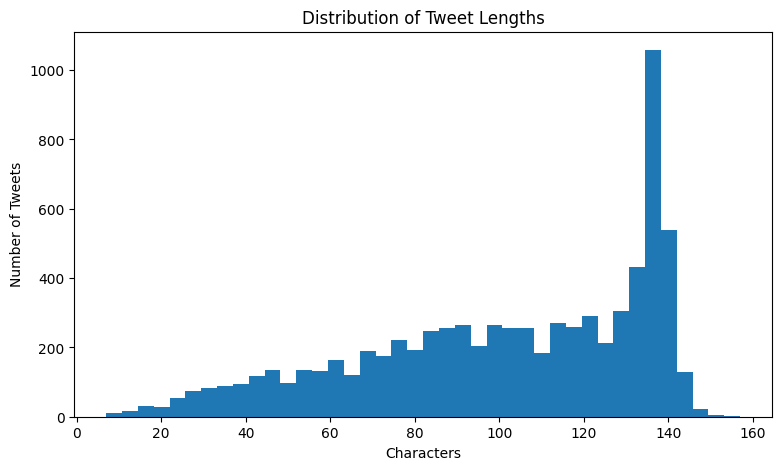

In [ ]:
train_text_lengths = train_df["text"].fillna("").astype(str).str.len()

print("Average tweet length:", train_text_lengths.mean())
print("Median tweet length:", train_text_lengths.median())
print("Maximum tweet length:", train_text_lengths.max())

plt.figure(figsize=(9, 5))
plt.hist(train_text_lengths, bins=40)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Characters")
plt.ylabel("Number of Tweets")
plt.show()


## 8. Train/Validation Split

We use a **stratified 80/20 split** so that both training and validation sets preserve the proportion of disaster and non-disaster tweets.

The validation set is used only for model comparison and threshold selection.


In [ ]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    all_text,
    train_df["target"],
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["target"]
)

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))


Training samples: 6090
Validation samples: 1523


## 9. TF-IDF Feature Engineering

We use two complementary TF-IDF representations:

### Word n-grams
Capture meaningful words and short phrases such as:

- `forest fire`
- `earthquake`
- `people missing`

### Character n-grams
Capture partial words, spelling variations, hashtags, and patterns inside words.

Combining both representations is often stronger than using only one.


In [ ]:
vectorizer = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            strip_accents="unicode",
            max_features=120000
        )
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=120000
        )
    )
])

X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)

print("Training TF-IDF shape:", X_train.shape)
print("Validation TF-IDF shape:", X_val.shape)


Training TF-IDF shape: (6090, 164028)
Validation TF-IDF shape: (1523, 164028)


## 10. Compare Multiple NLP Models

We compare three lightweight CPU-friendly classifiers:

1. Logistic Regression
2. Linear Support Vector Machine
3. Multinomial Naive Bayes

All models operate directly on the sparse TF-IDF matrix, so no GPU is required.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        C=2,
        max_iter=2000,
        random_state=SEED
    ),
    "Linear SVM": LinearSVC(
        C=0.5,
        random_state=SEED
    ),
    "Multinomial Naive Bayes": MultinomialNB(
        alpha=0.5
    )
}

model_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_val)[:, 1]
        predictions = (probabilities >= 0.50).astype(int)
    else:
        predictions = model.predict(X_val)

    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions),
    })

results_df = (
    pd.DataFrame(model_results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.813526,0.800325,0.753823,0.776378
1,Linear SVM,0.809586,0.792605,0.753823,0.772727
2,Multinomial Naive Bayes,0.811556,0.848197,0.683486,0.756986


## 11. Compare F1 Scores

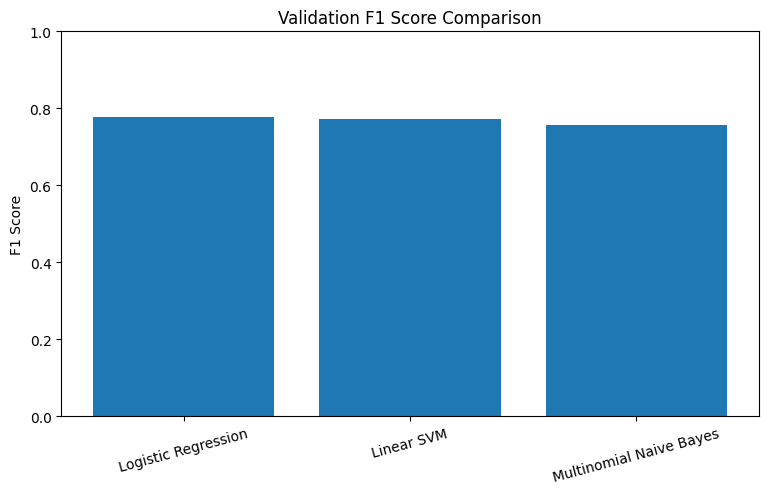

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["F1"]
)

plt.ylim(0, 1)
plt.title("Validation F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.show()


## 12. Tune Logistic Regression

Logistic Regression gives probabilities, which allows us to tune the classification threshold.

Because the competition metric is F1, the best threshold is not necessarily exactly `0.50`.

We search over a reasonable range of thresholds using the validation set.


In [ ]:
logreg = LogisticRegression(
    C=2,
    max_iter=2000,
    random_state=SEED
)

logreg.fit(X_train, y_train)

val_probabilities = logreg.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.01)

threshold_scores = []

for threshold in thresholds:
    predictions = (val_probabilities >= threshold).astype(int)

    threshold_scores.append({
        "Threshold": threshold,
        "F1": f1_score(y_val, predictions),
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
    })

threshold_df = pd.DataFrame(threshold_scores)

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(best_row["Threshold"])

print("Best threshold:", best_threshold)
print("Best validation F1:", f"{best_row['F1']:.4f}")

display(threshold_df.sort_values("F1", ascending=False).head(10))


Best threshold: 0.46000000000000013
Best validation F1: 0.7804


,Threshold,F1,Accuracy,Precision,Recall
16,0.46,0.780413,0.811556,0.781011,0.779817
17,0.47,0.779739,0.811556,0.782743,0.776758
15,0.45,0.779043,0.808930,0.773756,0.784404
18,0.48,0.778898,0.812869,0.790551,0.767584
19,0.49,0.777778,0.813526,0.796474,0.759939
14,0.44,0.776435,0.805647,0.767164,0.785933
20,0.50,0.776378,0.813526,0.800325,0.753823
22,0.52,0.774920,0.816152,0.816949,0.737003
21,0.51,0.773885,0.813526,0.807309,0.743119
13,0.43,0.773273,0.801707,0.759587,0.787462


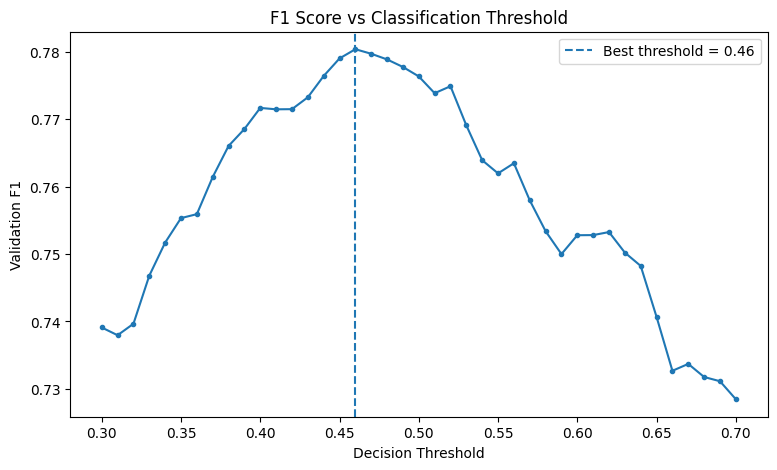

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    markersize=3
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Validation F1")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.show()


## 13. Final Validation Evaluation

We now evaluate the tuned Logistic Regression model using the threshold selected specifically for F1.


In [ ]:
final_val_pred = (
    val_probabilities >= best_threshold
).astype(int)

print("Validation Accuracy:", f"{accuracy_score(y_val, final_val_pred):.4f}")
print("Validation Precision:", f"{precision_score(y_val, final_val_pred):.4f}")
print("Validation Recall:", f"{recall_score(y_val, final_val_pred):.4f}")
print("Validation F1:", f"{f1_score(y_val, final_val_pred):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        final_val_pred,
        target_names=["Not Disaster", "Real Disaster"]
    )
)


Validation Accuracy: 0.8116
Validation Precision: 0.7810
Validation Recall: 0.7798
Validation F1: 0.7804

Classification Report:
               precision    recall  f1-score   support

 Not Disaster       0.83      0.84      0.83       869
Real Disaster       0.78      0.78      0.78       654

     accuracy                           0.81      1523
    macro avg       0.81      0.81      0.81      1523
 weighted avg       0.81      0.81      0.81      1523



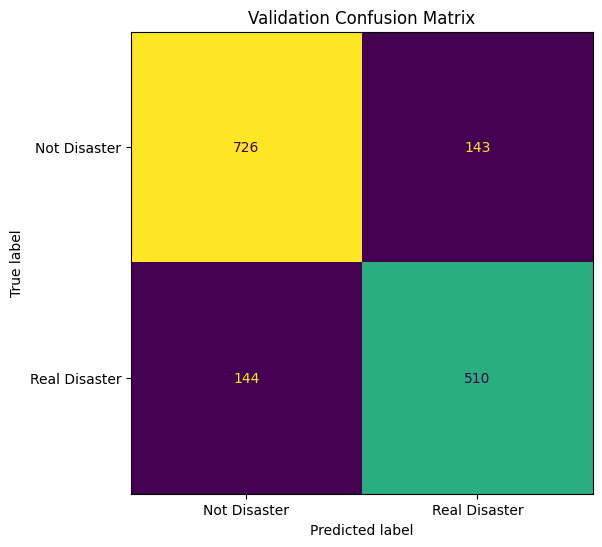

In [ ]:
cm = confusion_matrix(y_val, final_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Disaster", "Real Disaster"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Validation Confusion Matrix")
plt.show()


## 14. Retrain the Final Model on All Labeled Tweets

After selecting the vectorizer, model, and F1 threshold, we retrain the vectorizer and model using **all available labeled training data**.

This lets the final classifier learn from every training example before predicting the Kaggle test set.


In [ ]:
# Refit TF-IDF on all labeled data
final_vectorizer = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            strip_accents="unicode",
            max_features=120000
        )
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=120000
        )
    )
])

X_all_final = final_vectorizer.fit_transform(all_text)
X_test_final = final_vectorizer.transform(test_text)

print("Final training matrix:", X_all_final.shape)
print("Final test matrix:", X_test_final.shape)

final_model = LogisticRegression(
    C=2,
    max_iter=2000,
    random_state=SEED
)

final_model.fit(
    X_all_final,
    train_df["target"]
)

print("✅ Final model trained on all labeled data.")


Final training matrix: (7613, 188749)
Final test matrix: (3263, 188749)
✅ Final model trained on all labeled data.


## 15. Generate Test Predictions

The model returns a probability of being a real disaster.

We apply the F1-optimized validation threshold rather than blindly using `0.50`.


In [ ]:
test_probabilities = final_model.predict_proba(X_test_final)[:, 1]

test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

print("Predicted class distribution:")
display(
    pd.Series(test_predictions)
    .value_counts()
    .rename_axis("target")
    .to_frame("count")
)

display(
    test_df[["id", "text"]]
    .assign(target=test_predictions)
    .head(10)
)


Predicted class distribution:


,count
target,
0,1951
1,1312


,id,text,target
0,0,Just happened a terrible car crash,1
1,2,"Heard about #earthquake is different cities, stay safe everyone.",1
2,3,"there is a forest fire at spot pond, geese are fleeing across the street, I cannot save them all",1
3,9,Apocalypse lighting. #Spokane #wildfires,1
4,11,Typhoon Soudelor kills 28 in China and Taiwan,1
5,12,We're shaking...It's an earthquake,1
6,21,"They'd probably still show more life than Arsenal did yesterday, eh? EH?",0
7,22,Hey! How are you?,0
8,27,What a nice hat?,0
9,29,Fuck off!,0


## 16. Create the Kaggle Submission File

Kaggle's sample submission contains two columns:

- `id`
- `target`

We preserve the test-set ID order and insert our binary predictions.


In [ ]:
submission = sample_submission.copy()

# Make sure the IDs match the provided test set
assert submission["id"].tolist() == test_df["id"].tolist()

submission["target"] = test_predictions

submission_path = Path("submission.csv")
submission.to_csv(
    submission_path,
    index=False
)

print("✅ submission.csv created")
print("Path:", submission_path.resolve())
print("Shape:", submission.shape)

display(submission.head(10))


✅ submission.csv created
Path: /content/submission.csv
Shape: (3263, 2)


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


## 17. Validate the Submission

Before uploading to Kaggle, confirm:

- Exactly two columns are present.
- The number of rows matches the sample submission.
- IDs are preserved.
- Target predictions contain only `0` and `1`.
- There are no missing values.


In [ ]:
print("Submission columns:", submission.columns.tolist())
print("Expected columns:", sample_submission.columns.tolist())
print("Submission rows:", len(submission))
print("Expected rows:", len(sample_submission))
print("Missing target values:", submission["target"].isna().sum())
print("Unique predictions:", sorted(submission["target"].unique()))

assert submission.columns.tolist() == ["id", "target"]
assert len(submission) == len(sample_submission)
assert submission["id"].tolist() == sample_submission["id"].tolist()
assert submission["target"].isin([0, 1]).all()
assert submission["target"].notna().all()

print("\n✅ Submission file is valid.")


Submission columns: ['id', 'target']
Expected columns: ['id', 'target']
Submission rows: 3263
Expected rows: 3263
Missing target values: 0
Unique predictions: [np.int64(0), np.int64(1)]

✅ Submission file is valid.


## 18. Save the Model and TF-IDF Features

This optional section saves the trained components so the model can be reused without retraining.


In [ ]:
import joblib

joblib.dump(
    final_model,
    "disaster_tweet_logistic_regression.pkl"
)

joblib.dump(
    final_vectorizer,
    "disaster_tweet_tfidf.pkl"
)

print("✅ Model saved:")
print(" - disaster_tweet_logistic_regression.pkl")
print(" - disaster_tweet_tfidf.pkl")


✅ Model saved:
 - disaster_tweet_logistic_regression.pkl
 - disaster_tweet_tfidf.pkl


## 19. Final Conclusion

### What we built

This project implemented a complete classical NLP pipeline for disaster-tweet classification.

### Main techniques

- Data inspection and class-balance analysis
- Tweet text cleaning
- Keyword and location integration
- Word-level TF-IDF
- Character-level TF-IDF
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes
- F1-based model comparison
- Probability-threshold optimization
- Final retraining on all labeled data
- Kaggle-compatible submission generation

### Why F1 was prioritized

The competition uses **F1 score**, so the final decision threshold was selected to improve the balance between precision and recall rather than optimizing accuracy alone.

### Final output

The main file for Kaggle submission is:

```text
submission.csv
```

Upload that file to the competition's **Submit Predictions** page.

> A leaderboard score can differ from the validation F1 because Kaggle evaluates the predictions on a hidden test set. Avoid repeatedly changing the model just to chase the public leaderboard; the Kaggle competition documentation explicitly warns about public/private leaderboard overfitting.
